# Part 1: Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

pd.set_option("display.max_columns", 1000)

In [2]:
df_state = pd.read_csv("data/raw/hhs_state_timeseries.csv")

state
date
critical_staffing_shortage_today_yes
critical_staffing_shortage_today_no
critical_staffing_shortage_today_not_reported
critical_staffing_shortage_anticipated_within_week_yes
critical_staffing_shortage_anticipated_within_week_no
inpatient_beds
inpatient_beds_coverage
inpatient_beds_used
inpatient_beds_used_coverage
inpatient_beds_used_covid
inpatient_beds_used_covid_coverage

Combine critical_staffing_shortage_today_yes, critical_staffing_shortage_today_no
Combine critical_staffing_shortage_anticipated_within_week_yes, critical_staffing_shortage_anticipated_within_week_no
Join hospital dataset for total bedcount

In [3]:
list(df_state.columns)

['state',
 'date',
 'critical_staffing_shortage_today_yes',
 'critical_staffing_shortage_today_no',
 'critical_staffing_shortage_today_not_reported',
 'critical_staffing_shortage_anticipated_within_week_yes',
 'critical_staffing_shortage_anticipated_within_week_no',
 'critical_staffing_shortage_anticipated_within_week_not_reported',
 'hospital_onset_covid',
 'hospital_onset_covid_coverage',
 'inpatient_beds',
 'inpatient_beds_coverage',
 'inpatient_beds_used',
 'inpatient_beds_used_coverage',
 'inpatient_beds_used_covid',
 'inpatient_beds_used_covid_coverage',
 'previous_day_admission_adult_covid_confirmed',
 'previous_day_admission_adult_covid_confirmed_coverage',
 'previous_day_admission_adult_covid_suspected',
 'previous_day_admission_adult_covid_suspected_coverage',
 'previous_day_admission_pediatric_covid_confirmed',
 'previous_day_admission_pediatric_covid_confirmed_coverage',
 'previous_day_admission_pediatric_covid_suspected',
 'previous_day_admission_pediatric_covid_suspected_

## Preprocessing¶

In [4]:
to_delete = [
 'staffed_adult_icu_bed_occupancy',
 'staffed_adult_icu_bed_occupancy_coverage',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid_coverage',
 'staffed_icu_adult_patients_confirmed_covid',
 'staffed_icu_adult_patients_confirmed_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_covid',
 'total_adult_patients_hospitalized_confirmed_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_covid',
 'total_pediatric_patients_hospitalized_confirmed_covid_coverage',
 'total_staffed_adult_icu_beds',
 'total_staffed_adult_icu_beds_coverage',
 'adult_icu_bed_covid_utilization',
 'adult_icu_bed_covid_utilization_coverage',
 'adult_icu_bed_covid_utilization_numerator',
 'adult_icu_bed_covid_utilization_denominator',
 'adult_icu_bed_utilization',
 'adult_icu_bed_utilization_coverage',
 'adult_icu_bed_utilization_numerator',
 'adult_icu_bed_utilization_denominator',
 'geocoded_state',
 'all_pediatric_inpatient_bed_occupied',
 'all_pediatric_inpatient_bed_occupied_coverage',
 'all_pediatric_inpatient_beds',
 'all_pediatric_inpatient_beds_coverage',
 'staffed_icu_pediatric_patients_confirmed_covid',
 'staffed_icu_pediatric_patients_confirmed_covid_coverage',
 'staffed_pediatric_icu_bed_occupancy',
 'staffed_pediatric_icu_bed_occupancy_coverage',
 'total_staffed_pediatric_icu_beds',
 'total_staffed_pediatric_icu_beds_coverage']

In [5]:
df_state = df_state.drop(columns= to_delete)

In [6]:
df_state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81713 entries, 0 to 81712
Data columns (total 100 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   state                                                               81713 non-null  object 
 1   date                                                                81713 non-null  object 
 2   critical_staffing_shortage_today_yes                                81713 non-null  int64  
 3   critical_staffing_shortage_today_no                                 81713 non-null  int64  
 4   critical_staffing_shortage_today_not_reported                       81713 non-null  int64  
 5   critical_staffing_shortage_anticipated_within_week_yes              81713 non-null  int64  
 6   critical_staffing_shortage_anticipated_within_week_no               81713 non-null  int64  
 7   critical_sta

In [7]:
#Explains the same information as the percentage thats caculated with these numerators and denominators.
df_state = df_state.drop(columns = ["inpatient_beds_utilization_coverage", 
                        "inpatient_beds_utilization",
                        "percent_of_inpatients_with_covid",
                        "percent_of_inpatients_with_covid_coverage",
                        "inpatient_bed_covid_utilization",
                        "inpatient_bed_covid_utilization_coverage",
                         ])

In [8]:
df_state.columns

Index(['state', 'date', 'critical_staffing_shortage_today_yes',
       'critical_staffing_shortage_today_no',
       'critical_staffing_shortage_today_not_reported',
       'critical_staffing_shortage_anticipated_within_week_yes',
       'critical_staffing_shortage_anticipated_within_week_no',
       'critical_staffing_shortage_anticipated_within_week_not_reported',
       'hospital_onset_covid', 'hospital_onset_covid_coverage',
       'inpatient_beds', 'inpatient_beds_coverage', 'inpatient_beds_used',
       'inpatient_beds_used_coverage', 'inpatient_beds_used_covid',
       'inpatient_beds_used_covid_coverage',
       'previous_day_admission_adult_covid_confirmed',
       'previous_day_admission_adult_covid_confirmed_coverage',
       'previous_day_admission_adult_covid_suspected',
       'previous_day_admission_adult_covid_suspected_coverage',
       'previous_day_admission_pediatric_covid_confirmed',
       'previous_day_admission_pediatric_covid_confirmed_coverage',
       'previo

# Feature Engineering¶

In [9]:
# Coverage per state (row wise)
df_state["coverage_per_state"] = df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"] + df_state["critical_staffing_shortage_today_not_reported"]

In [10]:
# Normalized deaths per hostpital from covid 
df_state["deaths_covid"] = df_state["deaths_covid"] / (df_state["deaths_covid_coverage"])

# Staffing shortage ratio
df_state["state_staffing_shortage_ratio"] = df_state["critical_staffing_shortage_today_yes"] / (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"])

# Reporting completeness
df_state["state_staffing_reporting_completeness"] = (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"]) / (
    df_state["coverage_per_state"]
)

# Reporting for next week (staffing shortage) ratio
df_state["state_staffing_shortage_anticipation_ratio"] = df_state["critical_staffing_shortage_anticipated_within_week_yes"] / (df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"])

# Reporting for next week (staffing shortage) completeness
df_state["state_staffing_shortage_anticipation_completeness"] = (df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"]) / (
    df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"] + df_state["critical_staffing_shortage_anticipated_within_week_not_reported"] )

In [11]:
df_state = df_state.drop(columns = ["deaths_covid_coverage", "deaths_covid", "critical_staffing_shortage_anticipated_within_week_yes", "critical_staffing_shortage_anticipated_within_week_no",
                         "critical_staffing_shortage_anticipated_within_week_not_reported"])

In [12]:
# Normalized beds total per hospital 
df_state["hospital_inpatient_beds"] = df_state["inpatient_beds"] / (df_state["inpatient_beds_coverage"])

# Normalized beds used per hospital 
df_state["hospital_inpatient_beds_used"] = df_state["inpatient_beds_used"] / (df_state["inpatient_beds_used_coverage"])


#Normalized count for covid plus influenza patients
df_state["total_patients_hospitalized_confirmed_influenza_and_covid"] = df_state["total_patients_hospitalized_confirmed_influenza_and_covid"] / (df_state["total_patients_hospitalized_confirmed_influenza_and_covid_coverage"])


df_state = df_state.drop(columns = ["hospital_onset_covid_coverage", "inpatient_beds_coverage", "inpatient_beds_used_coverage", "inpatient_beds_used_covid_coverage",
"icu_patients_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_and_covid_coverage"])

In [13]:
df_state.columns

Index(['state', 'date', 'critical_staffing_shortage_today_yes',
       'critical_staffing_shortage_today_no',
       'critical_staffing_shortage_today_not_reported', 'hospital_onset_covid',
       'inpatient_beds', 'inpatient_beds_used', 'inpatient_beds_used_covid',
       'previous_day_admission_adult_covid_confirmed',
       'previous_day_admission_adult_covid_confirmed_coverage',
       'previous_day_admission_adult_covid_suspected',
       'previous_day_admission_adult_covid_suspected_coverage',
       'previous_day_admission_pediatric_covid_confirmed',
       'previous_day_admission_pediatric_covid_confirmed_coverage',
       'previous_day_admission_pediatric_covid_suspected',
       'previous_day_admission_pediatric_covid_suspected_coverage',
       'inpatient_beds_utilization_numerator',
       'inpatient_beds_utilization_denominator',
       'percent_of_inpatients_with_covid_numerator',
       'percent_of_inpatients_with_covid_denominator',
       'inpatient_bed_covid_utilizati

In [14]:
df_state = df_state.drop(columns = ["inpatient_beds_utilization_numerator",
"inpatient_beds_utilization_denominator",
'percent_of_inpatients_with_covid_numerator',
'percent_of_inpatients_with_covid_denominator',
'inpatient_bed_covid_utilization_numerator',
'inpatient_bed_covid_utilization_denominator', "critical_staffing_shortage_today_yes",
"critical_staffing_shortage_today_no", "critical_staffing_shortage_today_not_reported"]
       )

# Feature Engineering¶

In [15]:
df_state["previous_day_admission_adult_covid_suspected_80"] = df_state["previous_day_admission_adult_covid_suspected_80_"]
df_state = df_state.drop(columns="previous_day_admission_adult_covid_suspected_80_")

In [16]:
def normalize_cols(df:pd.DataFrame):
    df_normalized = df.copy()
    for col in df.columns:
        if "_coverage" in col:
            new_name = col.replace("_coverage", "")
            normalized = df[new_name] / df[col]
            df_normalized[new_name + "_normalized"] = normalized
            df_normalized = df_normalized.drop(columns=[col, new_name])
        elif '_utilization' in col:
            df_normalized.drop(columns=col)
        else:
            continue
    return df_normalized
df_normalized = normalize_cols(df_state)
df_normalized

,state,date,hospital_onset_covid,inpatient_beds,inpatient_beds_used,inpatient_beds_used_covid,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,on_hand_supply_therapeutic_b_bamlanivimab_courses,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,previous_week_therapeutic_a_casirivimab_imdevimab_courses_used,previous_week_therapeutic_b_bamlanivimab_courses_used,previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used,icu_patients_confirmed_influenza,total_patients_hospitalized_confirmed_influenza,total_patients_hospitalized_confirmed_influenza_and_covid,coverage_per_state,state_staffing_shortage_ratio,state_staffing_reporting_completeness,state_staffing_shortage_anticipation_ratio,state_staffing_shortage_anticipation_completeness,hospital_inpatient_beds,hospital_inpatient_beds_used,previous_day_admission_adult_covid_confirmed_normalized,previous_day_admission_adult_covid_suspected_normalized,previous_day_admission_pediatric_covid_confirmed_normalized,previous_day_admission_pediatric_covid_suspected_normalized,previous_day_admission_adult_covid_confirmed_18_19_normalized,previous_day_admission_adult_covid_confirmed_20_29_normalized,previous_day_admission_adult_covid_confirmed_30_39_normalized,previous_day_admission_adult_covid_confirmed_40_49_normalized,previous_day_admission_adult_covid_confirmed_50_59_normalized,previous_day_admission_adult_covid_confirmed_60_69_normalized,previous_day_admission_adult_covid_confirmed_70_79_normalized,previous_day_admission_adult_covid_confirmed_80_normalized,previous_day_admission_adult_covid_confirmed_unknown_normalized,previous_day_admission_adult_covid_suspected_18_19_normalized,previous_day_admission_adult_covid_suspected_20_29_normalized,previous_day_admission_adult_covid_suspected_30_39_normalized,previous_day_admission_adult_covid_suspected_40_49_normalized,previous_day_admission_adult_covid_suspected_50_59_normalized,previous_day_admission_adult_covid_suspected_60_69_normalized,previous_day_admission_adult_covid_suspected_70_79_normalized,previous_day_admission_adult_covid_suspected_80_normalized,previous_day_admission_adult_covid_suspected_unknown_normalized,previous_day_admission_influenza_confirmed_normalized,previous_day_deaths_covid_and_influenza_normalized,previous_day_deaths_influenza_normalized,previous_day_admission_pediatric_covid_confirmed_0_4_normalized,previous_day_admission_pediatric_covid_confirmed_12_17_normalized,previous_day_admission_pediatric_covid_confirmed_5_11_normalized,previous_day_admission_pediatric_covid_confirmed_unknown_normalized
0,AL,2020-01-01T00:00:00.000,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HI,2020-01-01T00:00:00.000,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IN,2020-01-01T00:00:00.000,0.0,30.0,15.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,30.000000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LA,2020-01-01T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MN,2020-01-01T00:00:00.000,0.0,46.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.000000,NaN,0.000000,46.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81708,VT,2024-04-2

## Final column drop of highly correlated or irrelevant features

In [17]:
df_normalized.columns

Index(['state', 'date', 'hospital_onset_covid', 'inpatient_beds',
       'inpatient_beds_used', 'inpatient_beds_used_covid',
       'on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses',
       'on_hand_supply_therapeutic_b_bamlanivimab_courses',
       'on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses',
       'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
       'previous_week_therapeutic_b_bamlanivimab_courses_used',
       'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
       'icu_patients_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza_and_covid',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness',
       'hospital_inpatient_beds', 'hospital_inpatient_beds_used',
     

In [18]:
df_normalized = df_normalized.drop(columns = ["inpatient_beds", "hospital_onset_covid", "inpatient_beds_used", "inpatient_beds_used_covid", "icu_patients_confirmed_influenza", "total_patients_hospitalized_confirmed_influenza",
"total_patients_hospitalized_confirmed_influenza_and_covid", "previous_day_deaths_influenza_normalized"])

# Final List of Columns:

For modeling rate use inpatient_beds_utilization without 'state', 'date', inpatient_beds', 'inpatient_beds_used',
'inpatient_beds_utilization_coverage',hospital_inpatient_beds_used
for modeling continous rv like hospital_inpatient_beds_used, exclude: "state", "date", 'inpatient_beds', 'inpatient_beds_used',
'inpatient_beds_utilization', 'inpatient_beds_utilization_coverage'

In [19]:
final_cols = list(df_normalized.columns)
df_normalized.columns 

Index(['state', 'date',
       'on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses',
       'on_hand_supply_therapeutic_b_bamlanivimab_courses',
       'on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses',
       'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
       'previous_week_therapeutic_b_bamlanivimab_courses_used',
       'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness',
       'hospital_inpatient_beds', 'hospital_inpatient_beds_used',
       'previous_day_admission_adult_covid_confirmed_normalized',
       'previous_day_admission_adult_covid_suspected_normalized',
       'previous_day_admission_pediatric_covid_confirmed_normalized',
       'previous_day_admission_pediatric_covid_suspected_normalized',
   

## Create Lagged Features

In [20]:
df_sorted = df_normalized.sort_values(["state", "date"]).copy()


In [21]:
df_sorted["beds_used_lag1"] = df_sorted.groupby("state")["hospital_inpatient_beds_used"].shift(7)
df_sorted["beds_used_lag2"] = df_sorted.groupby("state")["hospital_inpatient_beds_used"].shift(14)
df_sorted["beds_used_rolling4"] = df_sorted.groupby("state")["hospital_inpatient_beds_used"].transform(
    lambda x: x.shift(7).rolling(28).mean()
)

df_sorted["state_staffing_shortage_ratio_lag1"] = df_sorted.groupby("state")["state_staffing_shortage_ratio"].shift(7)
df_sorted["state_staffing_shortage_ratio_lag2"] = df_sorted.groupby("state")["state_staffing_shortage_ratio"].shift(14)
df_sorted["state_staffing_shortage_ratio_rolling4"] = df_sorted.groupby("state")["state_staffing_shortage_ratio"].transform(
    lambda x: x.shift(7).rolling(28).mean()
)

In [22]:
df_sorted = df_sorted.drop(columns = ['previous_day_admission_pediatric_covid_confirmed_normalized',
       'previous_day_admission_adult_covid_confirmed_normalized',
       'previous_day_admission_adult_covid_suspected_normalized',
       ])

## Final Column selection

In [23]:
df_columns_for_modeling = df_sorted.copy()

df_columns_for_modeling.columns

Index(['state', 'date',
       'on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses',
       'on_hand_supply_therapeutic_b_bamlanivimab_courses',
       'on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses',
       'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
       'previous_week_therapeutic_b_bamlanivimab_courses_used',
       'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness',
       'hospital_inpatient_beds', 'hospital_inpatient_beds_used',
       'previous_day_admission_pediatric_covid_suspected_normalized',
       'previous_day_admission_adult_covid_confirmed_18_19_normalized',
       'previous_day_admission_adult_covid_confirmed_20_29_normalized',
       'previous_day_admission_adult_covid_confirmed_30_39_no

In [24]:
df_columns_for_modeling.to_csv('data/clean/final_featuresv2.csv', index=False)

In [25]:
df_sorted

,state,date,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,on_hand_supply_therapeutic_b_bamlanivimab_courses,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,previous_week_therapeutic_a_casirivimab_imdevimab_courses_used,previous_week_therapeutic_b_bamlanivimab_courses_used,previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used,coverage_per_state,state_staffing_shortage_ratio,state_staffing_reporting_completeness,state_staffing_shortage_anticipation_ratio,state_staffing_shortage_anticipation_completeness,hospital_inpatient_beds,hospital_inpatient_beds_used,previous_day_admission_pediatric_covid_suspected_normalized,previous_day_admission_adult_covid_confirmed_18_19_normalized,previous_day_admission_adult_covid_confirmed_20_29_normalized,previous_day_admission_adult_covid_confirmed_30_39_normalized,previous_day_admission_adult_covid_confirmed_40_49_normalized,previous_day_admission_adult_covid_confirmed_50_59_normalized,previous_day_admission_adult_covid_confirmed_60_69_normalized,previous_day_admission_adult_covid_confirmed_70_79_normalized,previous_day_admission_adult_covid_confirmed_80_normalized,previous_day_admission_adult_covid_confirmed_unknown_normalized,previous_day_admission_adult_covid_suspected_18_19_normalized,previous_day_admission_adult_covid_suspected_20_29_normalized,previous_day_admission_adult_covid_suspected_30_39_normalized,previous_day_admission_adult_covid_suspected_40_49_normalized,previous_day_admission_adult_covid_suspected_50_59_normalized,previous_day_admission_adult_covid_suspected_60_69_normalized,previous_day_admission_adult_covid_suspected_70_79_normalized,previous_day_admission_adult_covid_suspected_80_normalized,previous_day_admission_adult_covid_suspected_unknown_normalized,previous_day_admission_influenza_confirmed_normalized,previous_day_deaths_covid_and_influenza_normalized,previous_day_admission_pediatric_covid_confirmed_0_4_normalized,previous_day_admission_pediatric_covid_confirmed_12_17_normalized,previous_day_admission_pediatric_covid_confirmed_5_11_normalized,previous_day_admission_pediatric_covid_confirmed_unknown_normalized,beds_used_lag1,beds_used_lag2,beds_used_rolling4,state_staffing_shortage_ratio_lag1,state_staffing_shortage_ratio_lag2,state_staffing_shortage_ratio_rolling4
1434,AK,2020-03-23T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.0,NaN,0.000000,56.000000,21.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1479,AK,2020-03-24T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.0,NaN,0.000000,56.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1525,AK,2020-03-25T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.0,NaN,0.000000,56.000000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1572,AK,2020-03-26T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0.0,NaN,0.000000,56.000000,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1619,AK,2020-03-27T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,0.0,NaN,0.000000,40.500000,11.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81496,WY,2024-04-23T00:00:00.000,2.0,NaN,99.0,0.0,NaN,0.0,27,NaN,0.0,0.050000,0.740741,48.074074,21.777778,0.000000,0.0,0.0,0.0,0.0,0.0,0.037037,0.000000,0.037037,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.150000,0.05,0.100000,0.0,0.037037,0.0,0.0,0.0,0.0,0.0,22.208333,22.840000,21.217077,NaN,NaN,NaN
81550,WY,2024-04-24T00:00:00.000,81.0,NaN,115.0,0.0,NaN,0.0,26,NaN,0.0,0.052632,0.730769,48.846

# Part 3: Random Forest Regressor

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

In [27]:
def mse(y_true, predictions):
    n = len(y_true)
    return np.sum((y_true - predictions)** 2) / n


mse_tracker = {}

### Data Loading & Cleaning

In [115]:
df = pd.read_csv('data/clean/final_featuresv2.csv')

exclude_cols = [
    "hospital_inpatient_beds", "coverage_per_state",
    #lots of missing values for pediatric admission attributes
    'previous_day_admission_pediatric_covid_confirmed_12_17_normalized',
    'previous_day_admission_pediatric_covid_confirmed_5_11_normalized',
    'previous_day_admission_pediatric_covid_confirmed_unknown_normalized',
    'previous_day_admission_pediatric_covid_confirmed_0_4_normalized'
]
columns_of_interest = [c for c in df.columns if c not in exclude_cols]

df = df[columns_of_interest].copy()

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81713 entries, 0 to 81712
Data columns (total 40 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   state                                                             81713 non-null  object 
 1   date                                                              81713 non-null  object 
 2   on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses        63546 non-null  float64
 3   on_hand_supply_therapeutic_b_bamlanivimab_courses                 61432 non-null  float64
 4   on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses      58856 non-null  float64
 5   previous_week_therapeutic_a_casirivimab_imdevimab_courses_used    63585 non-null  float64
 6   previous_week_therapeutic_b_bamlanivimab_courses_used             61505 non-null  float64
 7   previous_week_therapeutic_c_bam

In [117]:
df = df.dropna()

In [118]:
df.shape

(54419, 40)

### Random Forest — Predicting `inpatient_beds_used`

### Split into train and test data based on the 80 percent quantile of date

In [119]:
SEED = 42

df["date"] = pd.to_datetime(df["date"])
cutoff_date = df["date"].quantile(0.8)

train = df[df["date"] <= cutoff_date]
test = df[df["date"] > cutoff_date]

train_sorted = train.sort_values(["date"]).copy()
test_sorted = test.sort_values(["date"]).copy()

X_train = train_sorted.drop(columns = ["hospital_inpatient_beds_used", "date", "state"]).copy()
y_train = train_sorted["hospital_inpatient_beds_used"]

X_test = test_sorted.drop(columns = ["hospital_inpatient_beds_used", "date", "state"]).copy()
y_test = test_sorted["hospital_inpatient_beds_used"]


In [145]:
train_sorted

,state,date,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,on_hand_supply_therapeutic_b_bamlanivimab_courses,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,previous_week_therapeutic_a_casirivimab_imdevimab_courses_used,previous_week_therapeutic_b_bamlanivimab_courses_used,previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used,state_staffing_shortage_ratio,state_staffing_reporting_completeness,state_staffing_shortage_anticipation_ratio,state_staffing_shortage_anticipation_completeness,hospital_inpatient_beds_used,previous_day_admission_pediatric_covid_suspected_normalized,previous_day_admission_adult_covid_confirmed_18_19_normalized,previous_day_admission_adult_covid_confirmed_20_29_normalized,previous_day_admission_adult_covid_confirmed_30_39_normalized,previous_day_admission_adult_covid_confirmed_40_49_normalized,previous_day_admission_adult_covid_confirmed_50_59_normalized,previous_day_admission_adult_covid_confirmed_60_69_normalized,previous_day_admission_adult_covid_confirmed_70_79_normalized,previous_day_admission_adult_covid_confirmed_80_normalized,previous_day_admission_adult_covid_confirmed_unknown_normalized,previous_day_admission_adult_covid_suspected_18_19_normalized,previous_day_admission_adult_covid_suspected_20_29_normalized,previous_day_admission_adult_covid_suspected_30_39_normalized,previous_day_admission_adult_covid_suspected_40_49_normalized,previous_day_admission_adult_covid_suspected_50_59_normalized,previous_day_admission_adult_covid_suspected_60_69_normalized,previous_day_admission_adult_covid_suspected_70_79_normalized,previous_day_admission_adult_covid_suspected_80_normalized,previous_day_admission_adult_covid_suspected_unknown_normalized,previous_day_admission_influenza_confirmed_normalized,previous_day_deaths_covid_and_influenza_normalized,beds_used_lag1,beds_used_lag2,beds_used_rolling4,state_staffing_shortage_ratio_lag1,state_staffing_shortage_ratio_lag2,state_staffing_shortage_ratio_rolling4
68392,TX,2020-12-14,24.0,15.0,0.0,0.0,0.0,0.0,0.276339,0.991438,0.333333,0.991438,87.592466,0.088083,0.011986,0.111301,0.128425,0.198630,0.250000,0.369863,0.422945,0.306507,0.118151,0.008636,0.062176,0.086356,0.119171,0.169550,0.202073,0.167820,0.136442,0.060449,0.050086,0.008636,87.611684,85.845095,90.282775,0.268631,0.263889,0.254581
72891,VI,2020-12-14,0.0,10.0,0.0,0.0,0.0,0.0,0.500000,1.000000,1.000000,1.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,46.000000,46.000000,45.285714,0.500000,0.500000,0.500000
68393,TX,2020-12-15,24.0,15.0,0.0,0.0,0.0,0.0,0.269430,0.991438,0.310881,0.991438,91.638699,0.107081,0.013699,0.094178,0.128425,0.224315,0.351027,0.488014,0.510274,0.371575,0.106164,0.010363,0.093264,0.110535,0.115717,0.216263,0.265976,0.254325,0.158895,0.053541,0.046632,0.008636,90.794872,90.905336,90.335609,0.265517,0.255208,0.255555
72892,VI,2020-12-15,0.0,10.0,0.0,0.0,0.0,0.0,0.500000,1.000000,1.000000,1.000000,46.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.000000,49.000000,45.267857,0.500000,0.500000,0.500000
72893,VI,2020-12-16,0.0,10.0,0.0,0.0,0.0,0.0,0.500000,1.000000,1.000000,1.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.500000,45.500000,44.839286,0.500000,0.500000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70862,UT,2023-08-11,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.096154,0.000000,0.826923,73.000000,0.000000,0.000000,0.000000,0.019608,0.000000,0.039216,0.019608,0.000

### WITHOUT LAG FEATURES

In [126]:
X_train_wo_lag = train_sorted.drop(columns = ["hospital_inpatient_beds_used", "date", "state", "beds_used_lag1", "beds_used_lag2", "beds_used_rolling4"])
X_test_wo_lag = test_sorted.drop(columns = ["hospital_inpatient_beds_used", "date", "state", "beds_used_lag1", "beds_used_lag2", "beds_used_rolling4"])

In [127]:
rfr_wolag = RandomForestRegressor(n_estimators= 1000, random_state=SEED, max_features= "sqrt", n_jobs= -1)

rfr_wolag.fit(X_train_wo_lag, y_train)


,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
r2_train = r2_score(y_train, rfr_wolag.predict(X_train_wo_lag))
r2_test  = r2_score(y_test,  rfr_wolag.predict(X_test_wo_lag))
rfr_wolag_pred = rfr_wolag.predict(X_test_wo_lag)

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")
print(f"MSE for RFR without lag features: {mse(y_test, rfr_wolag_pred)}")

mse_tracker["RFR_wolag"] = mse(y_test, rfr_wolag_pred)


Train R²: 0.9935
Test  R²: 0.6245
Gap:      0.3690  (>0.05 suggests overfitting)
MSE for RFR without lag features: 921.1729448073113


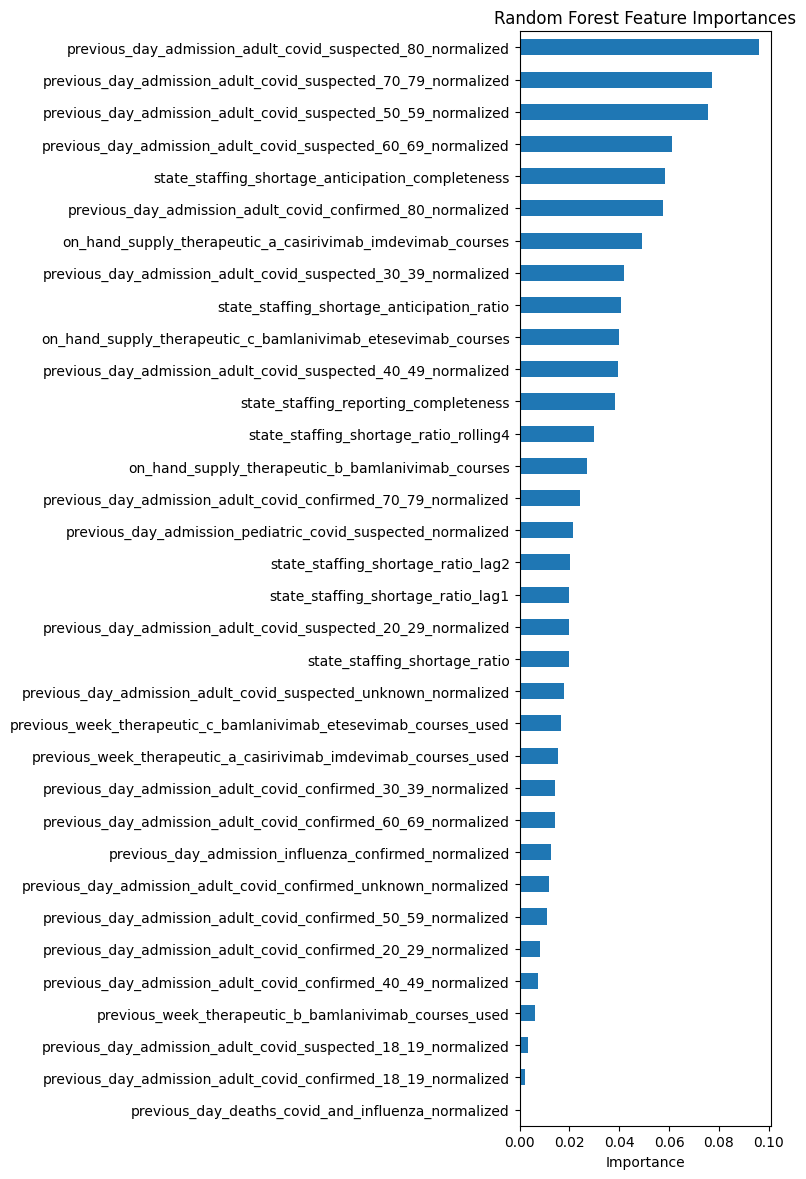

In [129]:
importances = pd.Series(rfr_wolag.feature_importances_, index=X_train_wo_lag.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

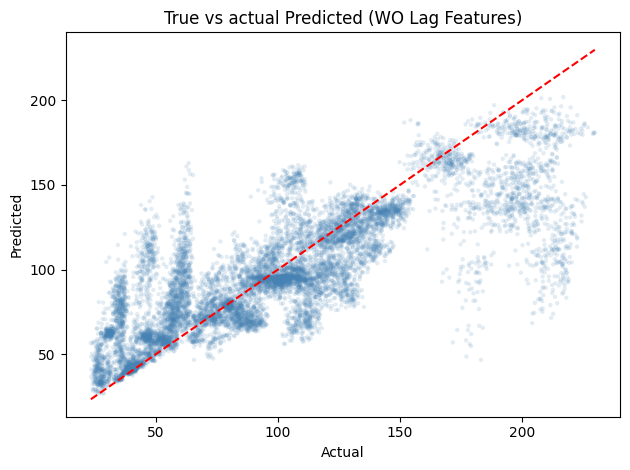

In [130]:
predictions = rfr_wolag.predict(X_test_wo_lag)
plt.scatter(y_test, predictions, alpha=0.15, s=10, color='steelblue', edgecolors='none')

lo = min(y_test.min(), predictions.min())
hi = max(y_test.max(), predictions.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

plt.title("True vs actual Predicted (WO Lag Features)")
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

### Analysis demonstrates the importance of lag features for the response variable in order to capture the larger values of per hospital inpatient beds used values.

## RFR With Lag Features

In [131]:
rfr = RandomForestRegressor(n_estimators= 100, random_state=SEED, max_features= "sqrt", n_jobs= -1)

rfr.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [132]:
r2_train = r2_score(y_train, rfr.predict(X_train))
r2_test  = r2_score(y_test,  rfr.predict(X_test))
rfr_predictions = rfr.predict(X_test)

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")
print(f"MSE for Random Forest Regressor: {mse(y_test, rfr_predictions)}")

mse_tracker["RFR"] = mse(y_test, rfr_predictions)

Train R²: 0.9995
Test  R²: 0.9909
Gap:      0.0086  (>0.05 suggests overfitting)
MSE for Random Forest Regressor: 22.271506284158782


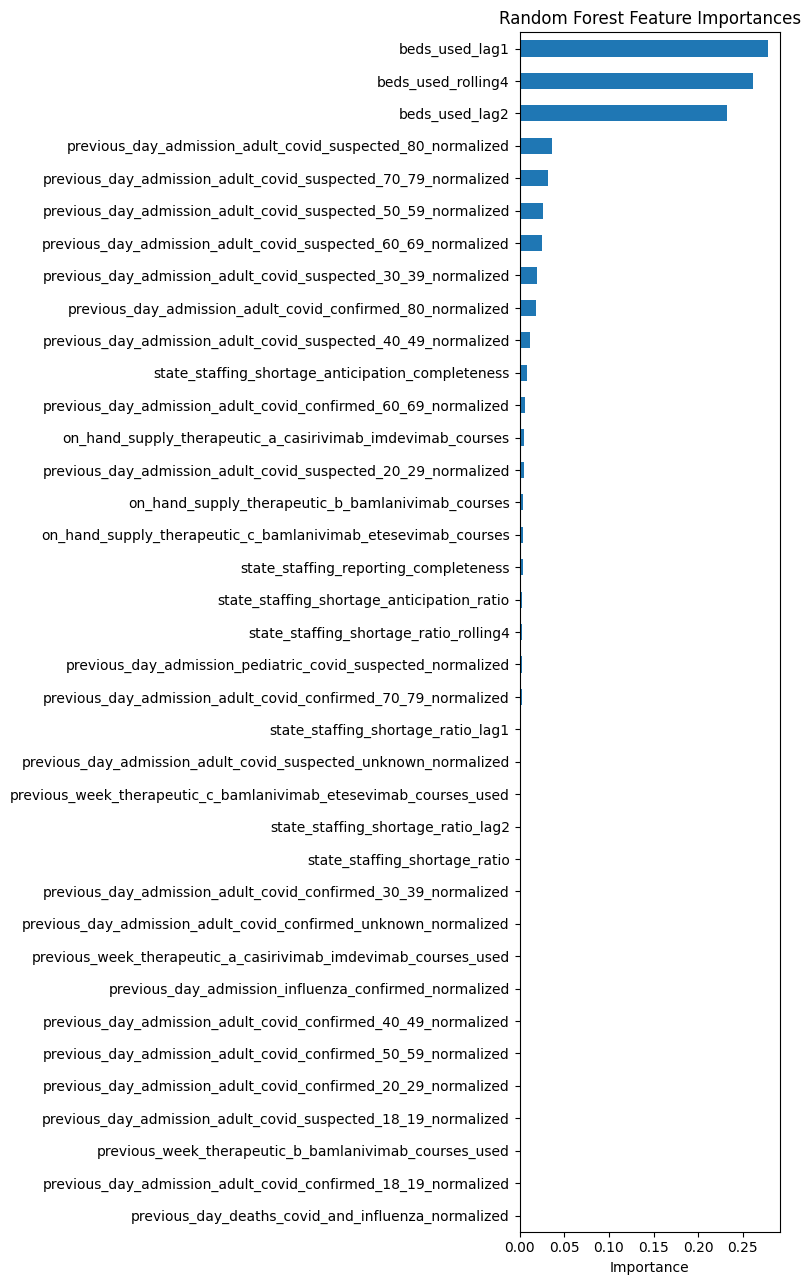

In [133]:
importances = pd.Series(rfr.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

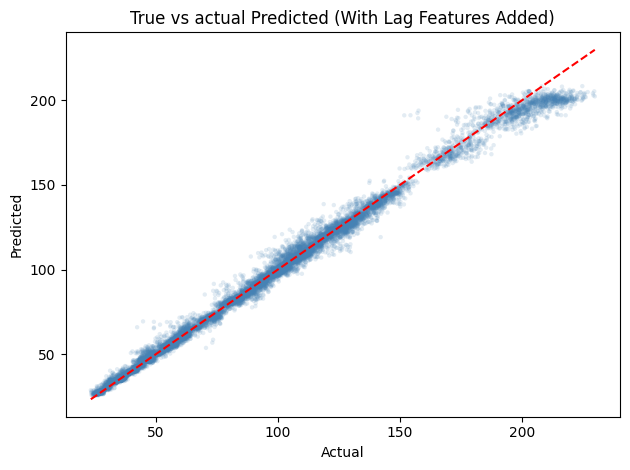

In [134]:
predictions = rfr.predict(X_test)
plt.scatter(y_test, predictions, alpha=0.15, s=10, color='steelblue', edgecolors='none')

lo = min(y_test.min(), predictions.min())
hi = max(y_test.max(), predictions.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

plt.title("True vs actual Predicted (With Lag Features Added)")
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

# XGBoost Model

In [135]:
from xgboost import XGBRegressor

XGBr = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, subsample = 0.5, colsample_bytree = 0.3)

XGBr.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.3
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [136]:
r2_train = r2_score(y_train, XGBr.predict(X_train))
r2_test  = r2_score(y_test,  XGBr.predict(X_test))
XGB_pred  = XGBr.predict(X_test)

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")
print(f"MSE for XGBRegressor: {mse(y_test, XGB_pred)}")

mse_tracker["XGBr"] = mse(y_test, XGB_pred)

Train R²: 0.9954
Test  R²: 0.9891
Gap:      0.0063  (>0.05 suggests overfitting)
MSE for XGBRegressor: 26.674834952893537


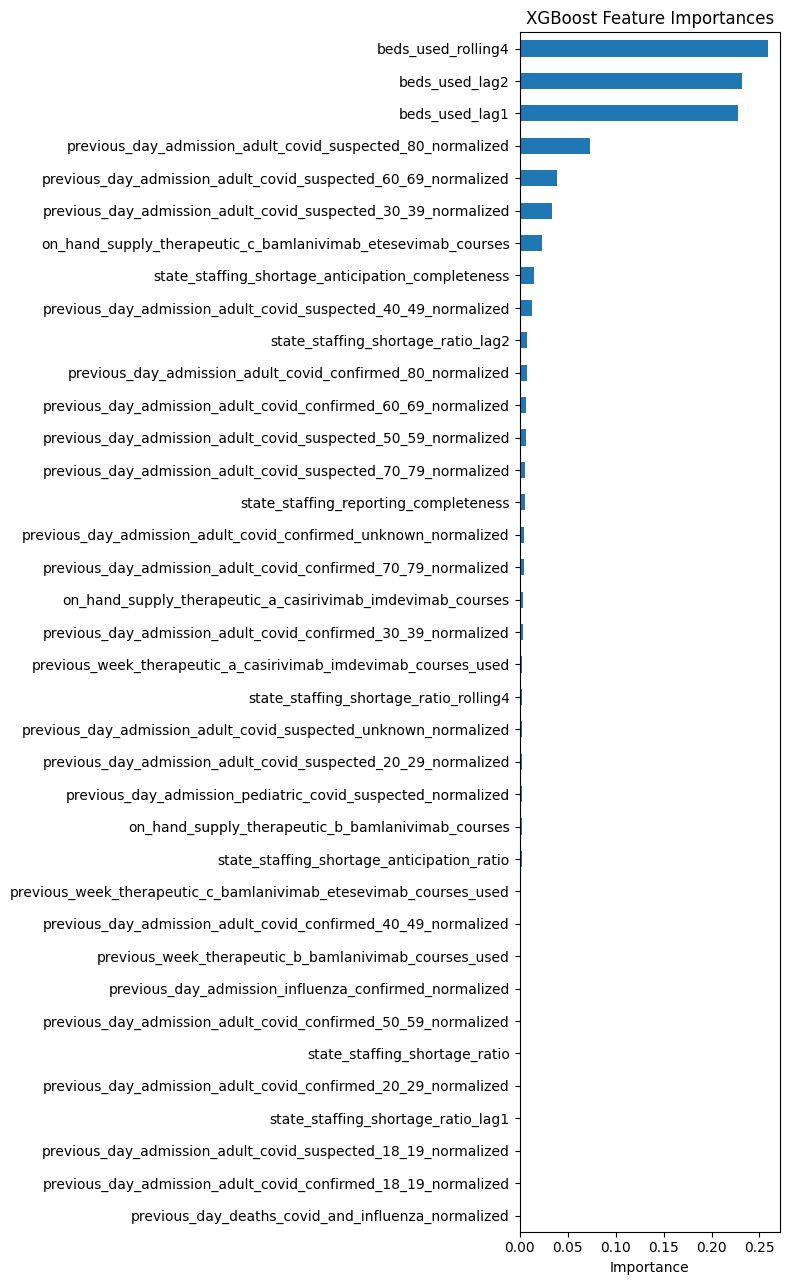

In [137]:
importances = pd.Series(XGBr.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('XGBoost Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

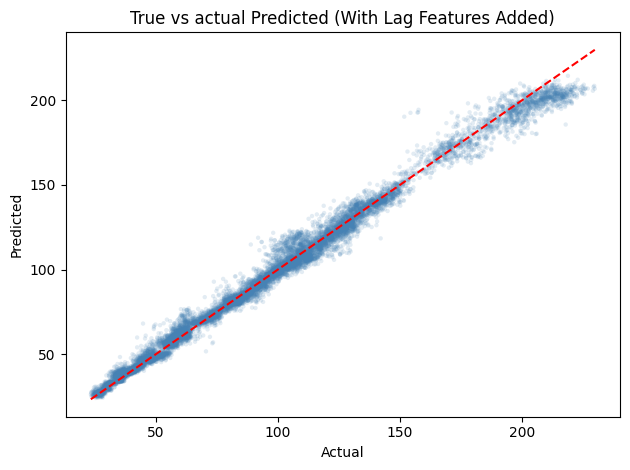

In [138]:
predictions = XGBr.predict(X_test)
plt.scatter(y_test, predictions, alpha=0.15, s=10, color='steelblue', edgecolors='none')

lo = min(y_test.min(), predictions.min())
hi = max(y_test.max(), predictions.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

plt.title("True vs actual Predicted (With Lag Features Added)")
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

# BASELINE MODEL (RIDGE REGRESSION)

In [187]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

scaler = StandardScaler()

X_trainscaled = scaler.fit_transform(X_train)
X_testscaled = scaler.transform(X_test)

In [189]:
ridge_model = Ridge(alpha = 1.0)

ridge_model.fit(X_trainscaled, y_train)
ridge_pred = ridge_model.predict(X_testscaled)

In [191]:
r2_train = r2_score(y_train, ridge_model.predict(X_trainscaled))
r2_test  = r2_score(y_test,  ridge_pred)

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")
print(f"MSE for Ridge Regression: {mse(y_test, ridge_pred)}")

mse_tracker["Ridge_regression"] = mse(y_test, ridge_pred)

Train R²: 0.9953
Test  R²: 0.9944
Gap:      0.0009  (>0.05 suggests overfitting)
MSE for Ridge Regression: 13.700960923962477


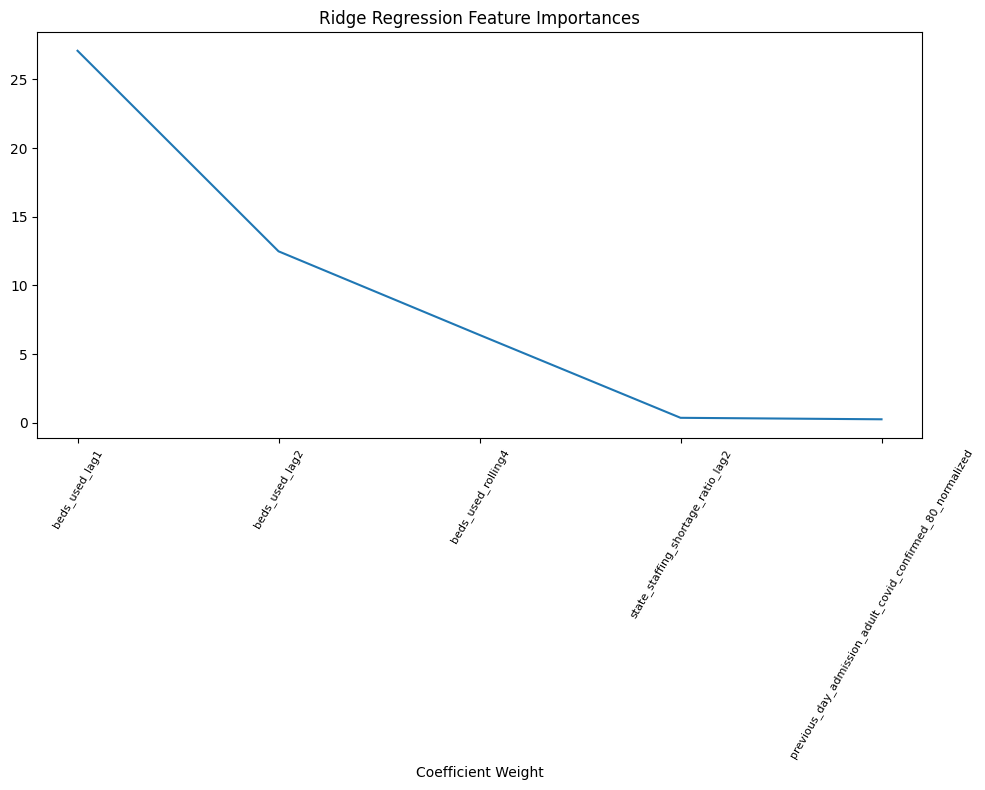

In [196]:
coeffs = pd.Series(ridge_model.coef_, index=X_train.columns).sort_values(ascending = False)

plt.figure(figsize=(10, 8))
plt.plot(list(coeffs.index[0:5]), coeffs[0:5])
plt.title('Ridge Regression Feature Importances')
plt.xlabel('Coefficient Weight')
plt.xticks(rotation = 60, fontsize = 8)
plt.tight_layout()
plt.show()

In [186]:
coeffs.sort_values(ascending=False)

beds_used_lag2                                                      32.301797
beds_used_rolling4                                                  13.444752
state_staffing_shortage_ratio_lag2                                   0.437662
previous_day_admission_adult_covid_confirmed_80_normalized           0.351027
previous_day_admission_adult_covid_confirmed_50_59_normalized        0.287324
previous_day_admission_adult_covid_suspected_60_69_normalized        0.272238
previous_day_admission_adult_covid_confirmed_40_49_normalized        0.217253
previous_day_admission_adult_covid_confirmed_70_79_normalized        0.165150
previous_day_admission_influenza_confirmed_normalized                0.131971
on_hand_supply_therapeutic_b_bamlanivimab_courses                    0.112550
state_staffing_shortage_ratio                                        0.111901
previous_day_admission_adult_covid_suspected_70_79_normalized        0.108601
previous_day_admission_adult_covid_confirmed_30_39_normalized   

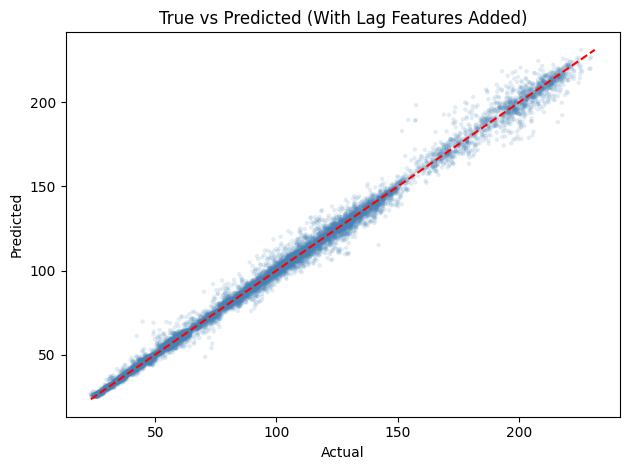

In [197]:
plt.scatter(y_test, ridge_pred, alpha=0.15, s=10, color='steelblue', edgecolors='none')

lo = min(y_test.min(), ridge_pred.min())
hi = max(y_test.max(), ridge_pred.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

plt.title("True vs Predicted (With Lag Features Added)")
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

# Light GBM model

In [199]:
import lightgbm as lgb

In [203]:
lgb_mod = lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, subsample = 0.5, colsample_bytree = 0.3)

lgb_mod.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9403
[LightGBM] [Info] Number of data points in the train set: 43545, number of used features: 37
[LightGBM] [Info] Start training from score 92.585573
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [206]:
r2_train = r2_score(y_train, lgb_mod.predict(X_train))
r2_test  = r2_score(y_test,  lgb_mod.predict(X_test))
lgb_pred  = lgb_mod.predict(X_test)

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")
print(f"MSE for LGBMRegressor: {mse(y_test, lgb_pred)}")

mse_tracker["LGBMr"] = mse(y_test, lgb_pred)

Train R²: 0.9949
Test  R²: 0.9864
Gap:      0.0085  (>0.05 suggests overfitting)
MSE for LGBMRegressor: 33.4050764208557


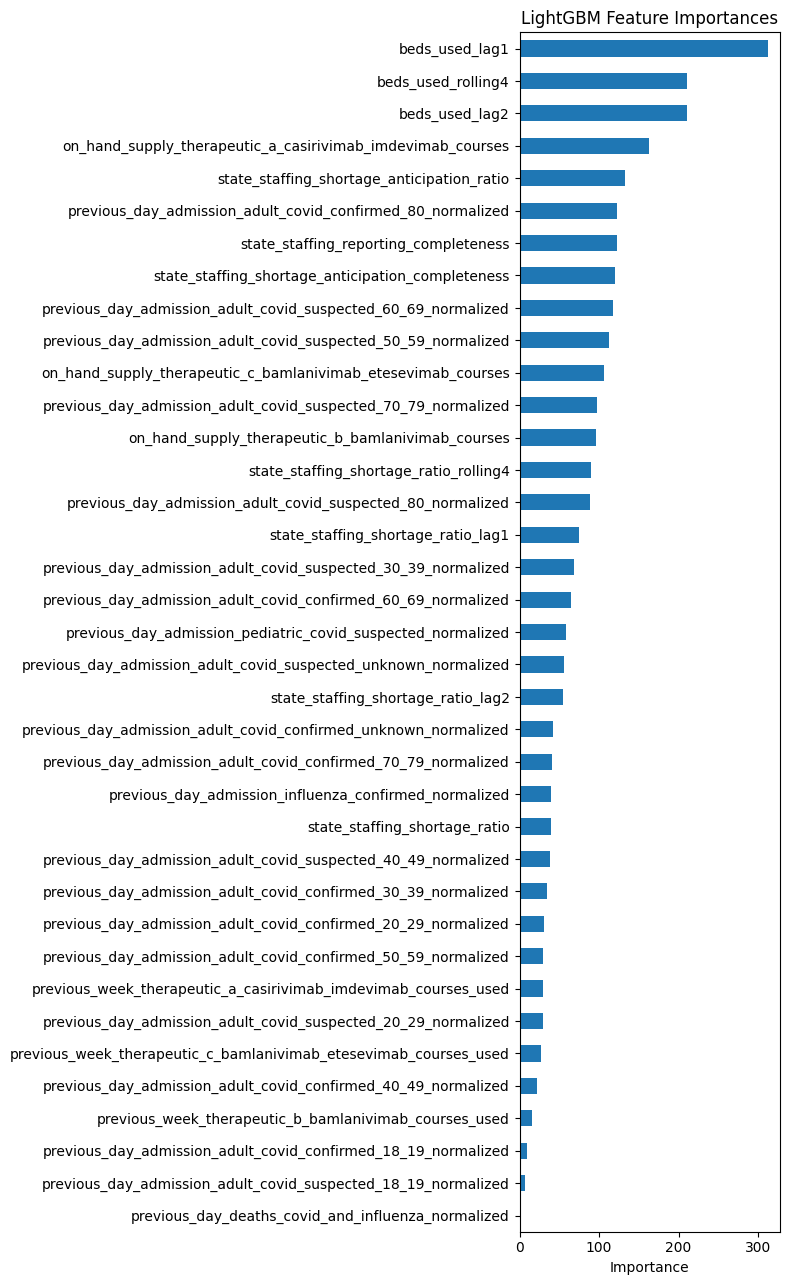

In [207]:
importances = pd.Series(lgb_mod.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('LightGBM Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

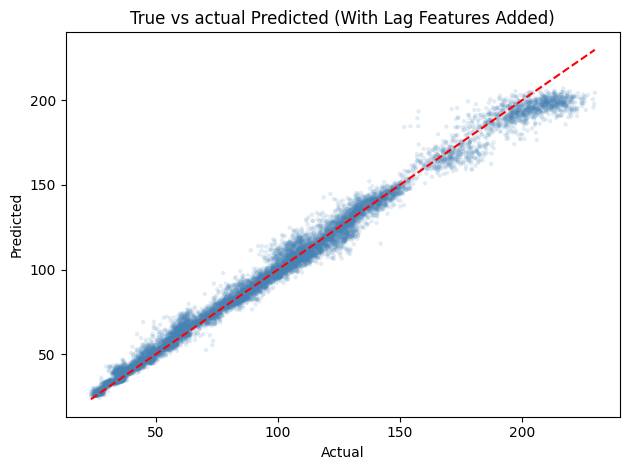

In [209]:
predictions = lgb_mod.predict(X_test)
plt.scatter(y_test, predictions, alpha=0.15, s=10, color='steelblue', edgecolors='none')

lo = min(y_test.min(), predictions.min())
hi = max(y_test.max(), predictions.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

plt.title("True vs actual Predicted (With Lag Features Added)")
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()